In [19]:
import os
import json
import time
import warnings
warnings.filterwarnings("ignore")

In [20]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

In [21]:
import pandas as pd
import numpy as np

In [22]:
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
    make_scorer
)
from sklearn.model_selection import KFold

In [23]:
from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer

In [24]:
pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 200)

In [25]:
RANDOM_STATE = 42
USE_GPU = False  # set True on Kaggle/Colab GPU sessions

In [26]:
# ---- 1. Load data ----
DATA_DIR = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset"  # <-- update as needed (Kaggle: /kaggle/input/.../kickstarter_joint_embeddings)

In [27]:
TRAIN_FILE = f"{DATA_DIR}/ML_train.csv"
TEST_FILE = f"{DATA_DIR}/ML_test.csv"
BERT_FILE = r"E:\NSU\cse445\EDA attempt3\NLP models\embeddings\bert_embeddings.csv"

In [28]:
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)
bert_raw = pd.read_csv(BERT_FILE)

In [29]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("BERT:", bert_raw.shape)

Train shape: (16000, 81)
Test shape: (4000, 81)
BERT: (20000, 769)


In [30]:
TARGET_RAW = "target_usd"
TARGET_LOG = "log_target"
DROP_FROM_X = ["id", "target_usd", "log_target", "goal_usd"]

In [31]:
train_ids = set(train_df["id"])
feature_cols = [c for c in bert_raw.columns if c != "id"]
FULL_DIM = len(feature_cols)  # 768
train_mask = bert_raw["id"].isin(train_ids)

In [32]:
# ---- 2. Evaluation helper ----
def evaluate_model(model_name, y_true_log, pred_log, actual_usd):
    pred_usd = np.expm1(pred_log)
    pred_usd = np.clip(pred_usd, a_min=0, a_max=None)

    mae_log = mean_absolute_error(y_true_log, pred_log)
    mse_log = mean_squared_error(y_true_log, pred_log)
    rmse_log = np.sqrt(mse_log)
    r2_log = r2_score(y_true_log, pred_log)

    mae_usd = mean_absolute_error(actual_usd, pred_usd)
    mse_usd = mean_squared_error(actual_usd, pred_usd)
    rmse_usd = np.sqrt(mse_usd)
    r2_usd = r2_score(actual_usd, pred_usd)

    rmsle = np.sqrt(mean_squared_log_error(actual_usd, pred_usd))

    return {
        "MAE_log":    mae_log,
        "MSE_log":    mse_log,
        "RMSE_log":   rmse_log,
        "R2_log":     r2_log,
        "MAE_USD":    mae_usd,
        "MSE_USD":    mse_usd,
        "RMSE_USD":   rmse_usd,
        "R2_USD":     r2_usd,
        "RMSLE":      rmsle
    }

In [33]:
# ---- 3. BayesSearchCV setup (fixed across all N_COMPONENTS) ----
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [34]:
rmse_scorer = make_scorer(rmse, greater_is_better=False)
CV = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
N_ITER_BAYES = 4

In [35]:
xgb_bayes_space = {
    "n_estimators":     Integer(200, 500),
    "learning_rate":    Real(0.01, 0.1, prior="log-uniform"),
    "max_depth":        Integer(4, 9),
    "min_child_weight": Integer(1, 7),
    "subsample":        Real(0.7, 1.0),
    "colsample_bytree": Real(0.7, 1.0),
    "reg_alpha":        Real(1e-3, 0.5, prior="log-uniform"),
    "reg_lambda":       Real(0.5, 3.0),
}

In [36]:
def make_search():
    base_estimator = XGBRegressor(
        objective="reg:squarederror", eval_metric="rmse",
        tree_method="hist", device="cuda" if USE_GPU else "cpu",
        random_state=RANDOM_STATE,
    )
    return BayesSearchCV(
        estimator=base_estimator, search_spaces=xgb_bayes_space, n_iter=N_ITER_BAYES,
        scoring=rmse_scorer, cv=CV, n_jobs=1,
        random_state=RANDOM_STATE, verbose=0, refit=True,
    )

In [37]:
# ---- 4. Ablation loop over N_COMPONENTS ----
N_COMPONENTS_LIST = [10, 20, 50, FULL_DIM]  # FULL_DIM (768) = no PCA, raw embedding

In [38]:
ablation_results = []
best_params_by_dim = {}

In [39]:
for n_comp in N_COMPONENTS_LIST:
    print(f"\n{'='*70}")
    print(f"N_COMPONENTS = {n_comp}")
    print(f"{'='*70}")

    if n_comp == FULL_DIM:
        # No PCA — use raw embedding directly
        reduced_cols = feature_cols
        reduced_df = bert_raw[["id"] + feature_cols].copy()
        explained = 1.0
    else:
        pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
        pca.fit(bert_raw.loc[train_mask, feature_cols])
        reduced_all = pca.transform(bert_raw[feature_cols])
        reduced_cols = [f"bert_pca_{i}" for i in range(n_comp)]
        reduced_df = pd.DataFrame(reduced_all, columns=reduced_cols)
        reduced_df.insert(0, "id", bert_raw["id"].values)
        explained = pca.explained_variance_ratio_.sum()

    print(f"Explained variance: {explained:.3f}")

    merged_train = train_df.merge(reduced_df, on="id", how="left")
    merged_test = test_df.merge(reduced_df, on="id", how="left")

    assert merged_train.shape[0] == train_df.shape[0], "Row count mismatch (train)"
    assert merged_test.shape[0] == test_df.shape[0], "Row count mismatch (test)"
    assert merged_train[reduced_cols].isna().sum().sum() == 0
    assert merged_test[reduced_cols].isna().sum().sum() == 0

    X_train = merged_train.drop(columns=DROP_FROM_X, errors="ignore")
    X_test = merged_test.drop(columns=DROP_FROM_X, errors="ignore")
    y_train = merged_train[TARGET_LOG].copy()
    y_test = merged_test[TARGET_LOG].copy()
    actual_usd = merged_test[TARGET_RAW].to_numpy()

    assert list(X_train.columns) == list(X_test.columns)

    search = make_search()
    start_time = time.time()
    search.fit(X_train, y_train)
    tuning_time = time.time() - start_time

    best_model = search.best_estimator_
    pred_log = best_model.predict(X_test)

    metrics = evaluate_model("BERT+XGBoost(Bayes)", y_test, pred_log, actual_usd)
    metrics["N_Components"] = n_comp
    metrics["Explained_Variance"] = explained
    metrics["Best_CV_RMSE_log"] = -search.best_score_
    metrics["Tuning_Time_Seconds"] = tuning_time

    ablation_results.append(metrics)
    best_params_by_dim[str(n_comp)] = dict(search.best_params_)

    print(f"RMSLE={metrics['RMSLE']:.4f} | R2_log={metrics['R2_log']:.4f} | "
          f"R2_USD={metrics['R2_USD']:.4f} | time={tuning_time:.1f}s")


N_COMPONENTS = 10
Explained variance: 0.600
RMSLE=1.6156 | R2_log=0.7220 | R2_USD=0.1378 | time=41.7s

N_COMPONENTS = 20
Explained variance: 0.727
RMSLE=1.5013 | R2_log=0.7594 | R2_USD=0.1800 | time=41.5s

N_COMPONENTS = 50
Explained variance: 0.874
RMSLE=1.3603 | R2_log=0.8028 | R2_USD=0.1963 | time=88.1s

N_COMPONENTS = 768
Explained variance: 1.000
RMSLE=1.1054 | R2_log=0.8697 | R2_USD=0.3168 | time=1116.3s


In [40]:
# ---- 5. Results table ----
results_df = pd.DataFrame(ablation_results)
results_df = results_df[[
    "N_Components", "Explained_Variance",
    "MAE_log", "MSE_log", "RMSE_log", "R2_log",
    "MAE_USD", "MSE_USD", "RMSE_USD", "R2_USD",
    "RMSLE", "Best_CV_RMSE_log", "Tuning_Time_Seconds"
]]
print("\n" + "="*70)
print("ABLATION RESULTS: BERT embedding dimensionality")
print("="*70)
print(results_df)


ABLATION RESULTS: BERT embedding dimensionality
   N_Components  Explained_Variance   MAE_log   MSE_log  RMSE_log    R2_log  \
0            10            0.599999  1.197276  2.612027  1.616177  0.721969   
1            20            0.726705  1.114757  2.260173  1.503387  0.759421   
2            50            0.874030  1.013964  1.852975  1.361240  0.802765   
3           768            1.000000  0.818535  1.224133  1.106406  0.869700   

        MAE_USD       MSE_USD       RMSE_USD    R2_USD     RMSLE  \
0  15060.239296  1.017567e+10  100874.537261  0.137764  1.615593   
1  14676.851224  9.677807e+09   98375.843819  0.179951  1.501253   
2  14244.259487  9.484581e+09   97388.814814  0.196324  1.360321   
3  12511.509803  8.063347e+09   89796.141914  0.316752  1.105353   

   Best_CV_RMSE_log  Tuning_Time_Seconds  
0          1.650068            41.747620  
1          1.539604            41.450413  
2          1.414323            88.057431  
3          1.215534          1116.286968  

In [41]:
results_df.to_csv("bert_pca_ablation_results.csv", index=False)
with open("bert_pca_ablation_best_params.json", "w") as f:
    json.dump(best_params_by_dim, f, indent=2, default=str)

In [42]:
print("\nSaved: bert_pca_ablation_results.csv")
print("Saved: bert_pca_ablation_best_params.json")


Saved: bert_pca_ablation_results.csv
Saved: bert_pca_ablation_best_params.json


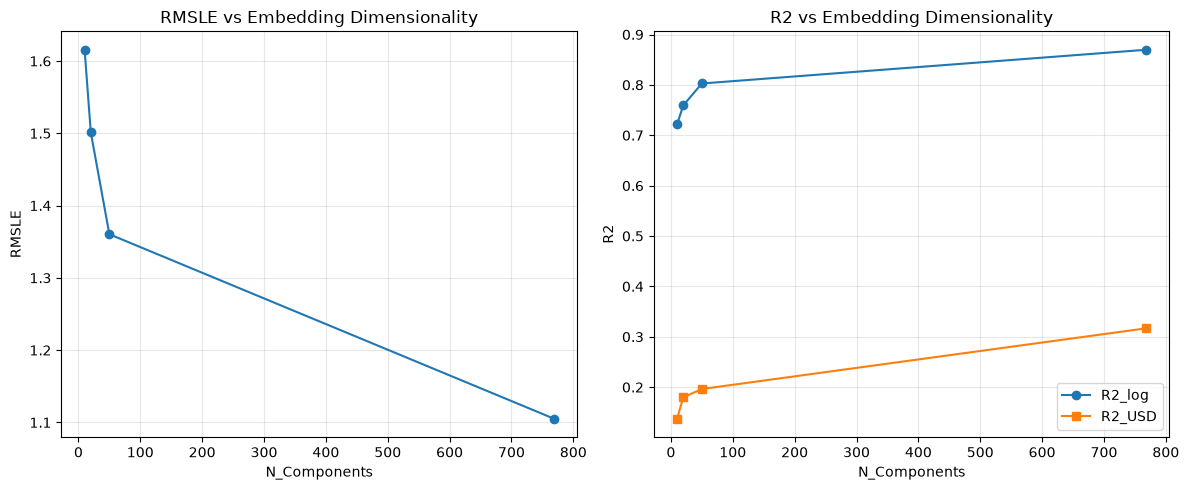

Saved: bert_pca_ablation_plot.png


In [47]:
# ---- 6. Plot RMSLE / R2 vs N_Components ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(results_df["N_Components"], results_df["RMSLE"], marker="o")
axes[0].set_xlabel("N_Components")
axes[0].set_ylabel("RMSLE")
axes[0].set_title("RMSLE vs Embedding Dimensionality")
axes[0].grid(True, alpha=0.3)
axes[1].plot(results_df["N_Components"], results_df["R2_log"], marker="o", label="R2_log")
axes[1].plot(results_df["N_Components"], results_df["R2_USD"], marker="s", label="R2_USD")
axes[1].set_xlabel("N_Components")
axes[1].set_ylabel("R2")
axes[1].set_title("R2 vs Embedding Dimensionality")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("bert_pca_ablation_plot.png", dpi=150)
plt.show()
print("Saved: bert_pca_ablation_plot.png")